<img src='https://hammondm.github.io/hltlogo1.png' style="float:right">

LING 593A-011<br>
Fall 2025<br>
Davo Acevedo-Cardona

## Standard Executive Titles

## Project Overview
**Task**: Provide a back-of-the-envelope list of the standard executive titles appearing in company 8-K and 10-K filings. 

**Dataset**: executives_final.csv  

---

## What This Pipeline Does?
1. **Load**: Reads the final cleaned executive dataset (`executive_final.csv`).  
2. **Normalize**: Standardizes capitalization and removes punctuation from titles.  
3. **Categorize**: Groups titles into broader executive categories.   
4. **Visualize**: Generates bar, pie and histogram charts of title distribution.

---

## Libraries Used

- **Packages**: `pandas`, `matplotlib`, `re`

---


## Pipeline

### Step 1: Configure / Knowing the data
```
INPUT_FILE = "executive_final.csv"
FINAL_FILE = "executive_titles_summary.csv"
```
### Step 2: Normalization
```
- Standardize text format (`.title()`)
- Remove punctuation and digits
- Create `title_clean` column
```
### Step 3: Categorization
Map each cleaned title to a normalized executive category

### Step 4: Visualization
- Bar Chart: Executive titles  
- Pie Chart: Distribution by executive category
- Histogram: Distribution of the executive titles

## Outputs:
1. CVS File: executive_titles_category_list 
2. Bar chatr: bar_chart.png
3. Pie chart: category_pie.png
4. Histogram: histogram_frequencies.png

# SET-UP

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import re

# Configuration
INPUT_FILE = "executive_final.csv"
FINAL_FILE = "executive_titles_summary.csv"

print(f"Loading file: {INPUT_FILE}")

Loading file: executive_final.csv


In [2]:
#Print some values:

filings_df = "executive_final.csv"

# Display some rows
df_sample = pd.read_csv(filings_df, nrows=5)

#Print
df_sample

,company,filing_type,executive_name,executive_title,confidence,executive_title_clean
0,1 800 FLOWERS COM INC,8-K,Moose Munch,Coo,spacy,Chief Operating Officer
1,"10x Genomics, Inc.",8-K,James Wilbur,Director,spacy,Director
2,1606 CORP.,8-K,Gregory Lambrecht,Chief Executive Officer,low,Chief Executive Officer
3,"1895 Bancorp of Wisconsin, Inc. /MD/",8-K,David Ball,Chief Executive Officer,spacy,Chief Executive Officer
4,"1stdibs.com, Inc.",8-K,Everette Taylor,Director,spacy,Director


# LOAD & CLEAN TITLES

In [3]:
# Step 1: Load and Basic Cleaning

# Load dataset
df = pd.read_csv(INPUT_FILE)
title_col = 'executive_title'

# Clean and normalize title text
df['title_clean'] = (
    df[title_col]
    .astype(str)
    .str.strip()
    .str.title()  # Standard capitalization
    .str.replace(r'[^a-zA-Z\s]', '', regex=True)  # regex to remove punctuation/numbers
)

pattern = r'^(Unknown\s*)$'
df.loc[df['title_clean'].str.match(pattern, case=False, na=True), 'title_clean'] = 'Unknown'

# Preview results
df[['executive_title', 'title_clean']].head(10)

,executive_title,title_clean
0,Coo,Coo
1,Director,Director
2,Chief Executive Officer,Chief Executive Officer
3,Chief Executive Officer,Chief Executive Officer
4,Director,Director
5,Ceo,Ceo
6,President Company,President Company
7,President,President
8,Coo,Coo
9,Chairman,Chairman


# Normalization

In [4]:
# STEP 2: Normalize Titles 

def normalize_title(t):
    """
    Normalize and classify executive titles by hierarchical importance.

    1. Chief Executive Officer (CEO)
    2. President
    3. Chief Operating Officer (COO)
    4. Chief Financial Officer (CFO)
    5. Chief Technology Officer / Chief Information Officer (CTO / CIO)
    6. Chief Marketing Officer (CMO)
    7. General Counsel / Chief Legal Officer (CLO)
    8. Vice President (VP / EVP / SVP)
    9. Director
    10. Treasurer / Controller
    11. Corporate Secretary
    12. Other Executive 
    """
    t = str(t).lower().strip()

    # Handle unknown or empty titles
    if t in ['unknown', 'na', 'n/a', 'none', '']:
        return 'Other Executive'

    # 1. CEO
    if re.search(r'\b(ceo|chief executive)\b', t):
        return 'Chief Executive Officer'

    # 2. Vice President (checked first to avoid overlap with President)
    elif re.search(r'\b(vice|svp|evp)\s+president\b', t):
        return 'Vice President'

    # 3. President (not preceded by Vice/SVP/EVP)
    elif re.search(r'(?<!vice\s)(?<!svp\s)(?<!evp\s)\bpresident\b', t):
        return 'President'

    # 4. COO
    elif re.search(r'\b(coo|chief operating)\b', t):
        return 'Chief Operating Officer'

    # 5. CFO
    elif re.search(r'\b(cfo|chief financial)\b', t):
        return 'Chief Financial Officer'

    # 6. CTO / CIO
    elif re.search(r'\b(cto|cio|chief technology|chief information)\b', t):
        return 'Chief Technology Officer'

    # 7. CMO
    elif re.search(r'\b(cmo|chief marketing)\b', t):
        return 'Chief Marketing Officer'

    # 8. General Counsel / CLO
    elif re.search(r'\b(general counsel|chief legal|chief counsel|clo)\b', t):
        return 'General Counsel'

    # 9. Director
    elif re.search(r'\bdirector\b', t):
        return 'Director'

    # 10. Treasurer / Controller / Finance
    elif re.search(r'\b(treasurer|controller|finance)\b', t):
        return 'Treasurer / Controller'

    # 11. Secretary
    elif re.search(r'\b(secretary)\b', t):
        return 'Corporate Secretary'

    # 12. Fallback
    else:
        return 'Other Executive'

# Apply normalization to the dataset
df['title_standard'] = df['title_clean'].apply(normalize_title)


print(df[['title_clean', 'title_standard']].head(10))

               title_clean           title_standard
0                      Coo  Chief Operating Officer
1                 Director                 Director
2  Chief Executive Officer  Chief Executive Officer
3  Chief Executive Officer  Chief Executive Officer
4                 Director                 Director
5                      Ceo  Chief Executive Officer
6        President Company                President
7                President                President
8                      Coo  Chief Operating Officer
9                 Chairman          Other Executive


# CATEGORIZATION

In [5]:
# STEP 3: CATEGORIZATION

def categorize_standard(t):
    """Assign each standardized title to a broader executive category."""
    t = str(t)

    # 1. C-Suite
    if 'Executive Officer' in t:
        return 'C-Suite: CEO'
    elif 'Financial Officer' in t:
        return 'C-Suite: CFO'
    elif 'Operating Officer' in t:
        return 'C-Suite: COO'
    elif 'Technology Officer' in t:
        return 'C-Suite: CTO'
    elif 'Marketing Officer' in t:
        return 'C-Suite: CMO'
    elif 'General Counsel' in t:
        return 'C-Suite: Legal'

    # 2. Vice President
    elif re.search(r'\bVice President\b', t, re.IGNORECASE):
        return 'VP/EVP/SVP'

    # 3. President
    elif re.search(r'\bPresident\b', t, re.IGNORECASE):
        return 'President'

    # 4. Director
    elif 'Director' in t:
        return 'Director'

    # 5. Finance-related titles
    elif 'Treasurer' in t or 'Controller' in t:
        return 'Finance Officer'

    # 6. Secretary
    elif 'Secretary' in t:
        return 'Corporate Secretary'

    # 7. Everything else
    else:
        return 'Other Executive'


# Apply categorization
df['category'] = df['title_standard'].apply(categorize_standard)

# Aggregate summary table
summary = (
    df.groupby(['title_standard', 'category'])
      .size()
      .reset_index(name='count')
      .sort_values(by='count', ascending=False)
)

# Export summary file
summary_file = "executive_titles_category.csv"
summary.to_csv(summary_file, index=False)

print(f"Summary exported to: {summary_file}")
print(f"Total unique titles: {len(summary)}\n")

print("\nStandardized titles by count:")
print(summary)

Summary exported to: executive_titles_category.csv
Total unique titles: 12


Standardized titles by count:
              title_standard             category  count
0    Chief Executive Officer         C-Suite: CEO   2499
6                   Director             Director   2097
11            Vice President           VP/EVP/SVP   1501
1    Chief Financial Officer         C-Suite: CFO   1447
9                  President            President   1416
8            Other Executive      Other Executive   1260
4   Chief Technology Officer         C-Suite: CTO    443
7            General Counsel       C-Suite: Legal    330
3    Chief Operating Officer         C-Suite: COO    194
5        Corporate Secretary  Corporate Secretary     44
10    Treasurer / Controller      Finance Officer     43
2    Chief Marketing Officer         C-Suite: CMO      9


# VISUALIZATION

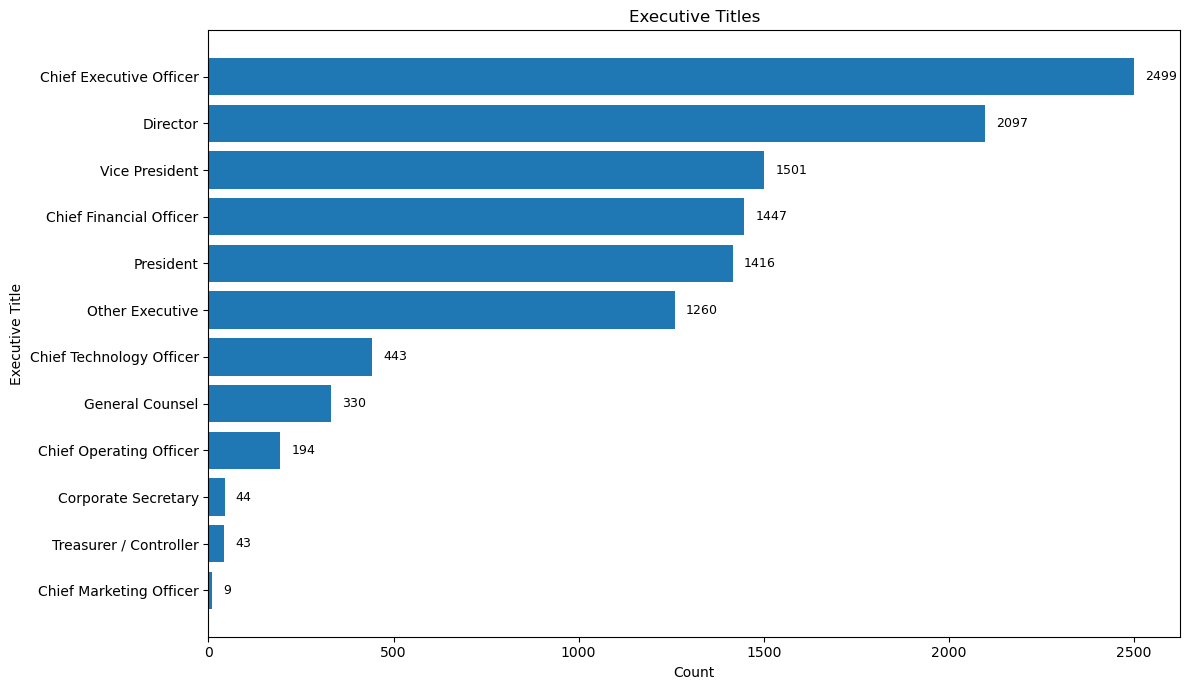

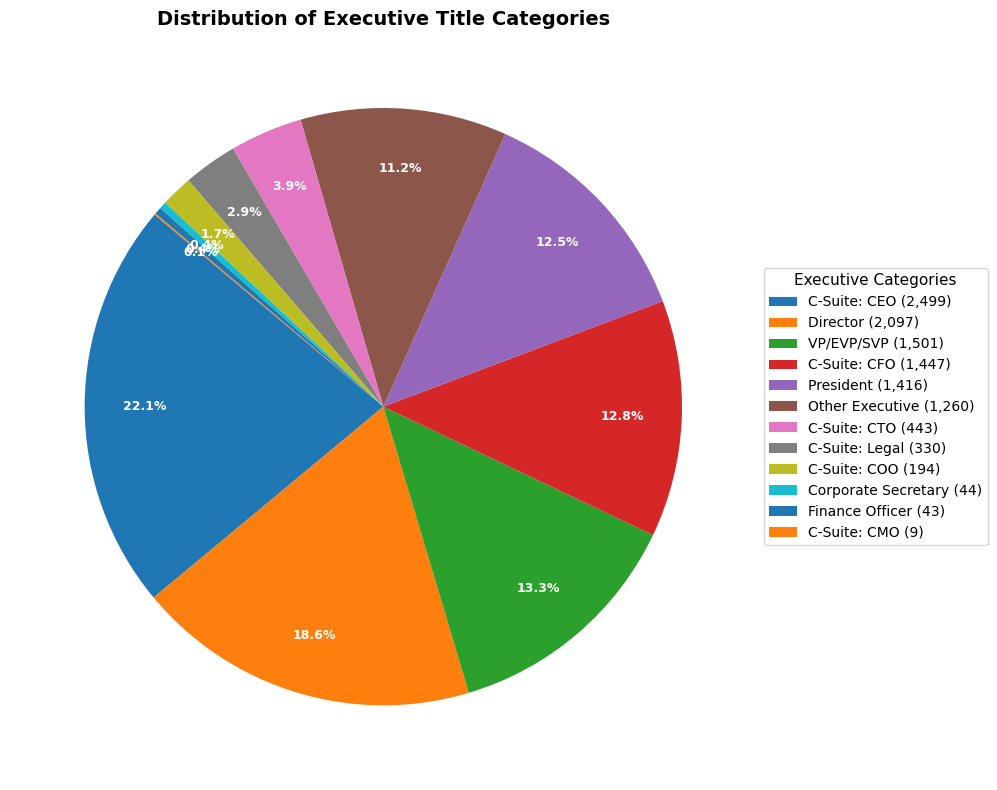

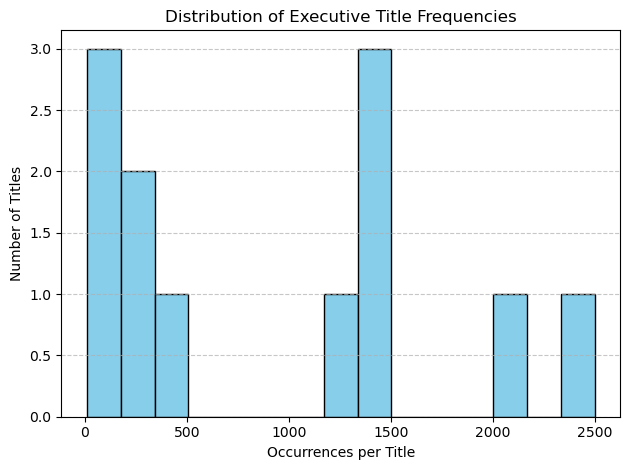

In [6]:
# Step 4: Visualization

# Bar Chart

plt.figure(figsize=(12,7))
sorted_summary = summary.sort_values(by='count', ascending=True)
bars = plt.barh(sorted_summary['title_standard'], sorted_summary['count'])

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 30, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=9)

plt.title("Executive Titles")
plt.xlabel("Count")
plt.ylabel("Executive Title")
plt.tight_layout()
plt.savefig("bar_chart.png", dpi=300)
plt.show()

#Pie Chart

plt.figure(figsize=(10,8))

# Group and sort categories by total count
cat_summary = (
    summary.groupby('category')['count']
    .sum()
    .reset_index()
    .sort_values(by='count', ascending=False)
)

# Pie chart with improved layout
wedges, texts, autotexts = plt.pie(
    cat_summary['count'],
    labels=None,                      
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

# Add legend instead of labels on slices
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    labels=[f"{c} ({v:,})" for c, v in zip(cat_summary['category'], cat_summary['count'])],
    title="Executive Categories",
    title_fontsize=11,
    fontsize=10
)

plt.setp(autotexts, size=9, weight="bold", color="white")

plt.title("Distribution of Executive Title Categories", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("category_pie.png", dpi=300)
plt.show()

# Histogram:
plt.hist(
    summary['count'],
    bins=15,             
    edgecolor='black',
    color='skyblue'
)

plt.title("Distribution of Executive Title Frequencies")
plt.xlabel("Occurrences per Title")
plt.ylabel("Number of Titles")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("histogram_frequencies.png", dpi=300)
plt.show()